# BraTS 2020 Data Preprocessing Pipeline
This notebook prepares the MRI dataset for the Latent Diffusion Model.

### **Pipeline Steps**
1.  **Smart Load:** Checks if data exists locally. If not, it downloads it from Kaggle automatically.
2.  **Normalization:** Scales all voxel intensities to `[-1, 1]` using Min-Max scaling.
3.  **Extraction:** Filters out empty slices and saves only **tumor-bearing slices**.
4.  **Packaging:** Bundles slices into `.pt` files (chunks of 2000) for efficient loading.

### **Prerequisites (Read Before Running)**
* **✅ If you already have the data:**
    Ensure your dataset folder is named **`BraTS2020_TrainingData`** and is located in this same directory. You do **not** need anything else.
    
* **⬇️ If you need to download the data :**
    You must have a **`kaggle.json`** file (API Token) to auto-download the dataset.
    1.  Go to your [Kaggle Settings](https://www.kaggle.com/settings).
    2.  Scroll to **API** → Click **"Create New Token"**.
    3.  Place the downloaded `kaggle.json` file **inside this folder** (next to this notebook).

In [1]:
import os
import kagglehub
import shutil

# --- SMART SETUP ---
# 1. The folder name on YOUR computer
local_folder = 'BraTS2020_TrainingData'

# 2. Logic: Check local first, else download
if os.path.exists(local_folder):
    print(f"✅ Found local dataset: '{local_folder}'")
    print("   Skipping download. Using local files.")
    path_to_use = local_folder

else:
    print(f"⚠️ Local folder '{local_folder}' not found.")
    print("   Initiating Kaggle download for teammate...")
    
    try:
        # Move credentials if they exist
        if os.path.exists('kaggle.json'):
            dest = os.path.expanduser('~/.kaggle')
            os.makedirs(dest, exist_ok=True)
            shutil.copy('kaggle.json', os.path.join(dest, 'kaggle.json'))
        
        # Download and capture path
        path_to_use = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
        print(f"✅ Download complete! Path: {path_to_use}")
        
    except Exception as e:
        print("❌ Error: Download failed. Please add 'kaggle.json' to this folder.")
        raise e

✅ Found local dataset: 'BraTS2020_TrainingData'
   Skipping download. Using local files.


# BraTS 2020 Preprocessing: Setup & File Discovery

This section initializes the environment and locates the MRI files.

### **Key Settings**
* **`DATASET_PATH`**: The folder containing the raw BraTS data.
* **`CHUNK_SIZE = 2000`**: We save processed data in batches of 2000 slices.
    * *Why?* Saving all 30,000+ slices into one file would crash your RAM. Splitting them into "packs" makes training efficient.

### **Step 1: File Discovery**
The code walks through the folder structure to find every `.nii` file that ends with `flair`. These serve as our "anchor" files to find the corresponding segmentation masks later.

In [2]:
import os
import numpy as np
import nibabel as nib
import torch
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
# NOTE: If you used the "Smart Loader" in the previous cell, 
# you can change this to: DATASET_PATH = path_to_use
DATASET_PATH = 'BraTS2020_TrainingData'

OUTPUT_PATH = 'processed_tumor_packs'
CHUNK_SIZE = 2000  # Save 2000 slices per file (Result: ~12 files total)

os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Looking for data in: {DATASET_PATH}...")

# --- 1. FIND FILES ---
files_found = []
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith('.nii') and 'flair' in file.lower():
            files_found.append(os.path.join(root, file))

print(f"Found {len(files_found)} patients. Starting Processing...")

Looking for data in: BraTS2020_TrainingData...
Found 369 patients. Starting Processing...


# BraTS 2020 Preprocessing: Normalization & Packing

This is the core engine of the pipeline. It iterates through every patient found in the previous step.

### **Processing Logic (Per Patient)**
1.  **Load Volumes:** We load the `FLAIR` (Brain Image) and `SEG` (Tumor Mask) using `nibabel`.
2.  **Global Normalization:**
    We scale the pixel intensities to a strict range of **[-1, 1]**. This is crucial for Latent Diffusion Models.
    $$x_{norm} = 2 \cdot \left( \frac{x - x_{min}}{x_{max} - x_{min}} \right) - 1$$
3.  **Slice & Filter:**
    * We convert the 3D volume into 2D slices.
    * **Filter:** We check `if np.max(seg_slice) > 0`. If the slice has no tumor, we throw it away. This removes useless "background" data.
4.  **Save in Packs:**
    * Slices are converted to `Float16` (to save storage space).
    * Once we collect `CHUNK_SIZE` (2000) slices, we save them as a `.pt` file and clear memory.

In [3]:
# --- 2. PROCESSING ---
current_chunk = []
pack_counter = 0
total_saved = 0

for flair_path in tqdm(files_found):
    try:
        # A. Path Setup (Find the matching segmentation file)
        seg_path = flair_path.replace('flair', 'seg').replace('FLAIR', 'seg')
        if not os.path.exists(seg_path):
            continue

        # B. Load 3D Volumes
        vol_flair = nib.load(flair_path).get_fdata()
        vol_seg = nib.load(seg_path).get_fdata()

        # --- STEP 1: CUSTOM GLOBAL NORMALIZATION (-1 to 1) ---
        min_v = np.min(vol_flair)
        max_v = np.max(vol_flair)
        range_v = max_v - min_v
        
        if range_v > 0:
            # Formula: x_norm = 2 * ((x - min) / (max - min)) - 1
            vol_flair = 2 * ((vol_flair - min_v) / range_v) - 1
        else:
            continue

        # --- STEP 2: SLICE AND FILTER ---
        total_slices = vol_flair.shape[2]

        for i in range(total_slices):
            seg_slice = vol_seg[:, :, i]

            # FILTER: Only keep if tumor exists (Max value > 0)
            if np.max(seg_slice) > 0:

                flair_slice = vol_flair[:, :, i]

                # Convert to Float16 (Half) to save space
                t_img = torch.from_numpy(flair_slice).half().unsqueeze(0)
                t_seg = torch.from_numpy(seg_slice).half().unsqueeze(0)

                # Combine -> [2, 240, 240] (Channel 0=Image, Channel 1=Mask)
                combined = torch.cat([t_img, t_seg], dim=0)

                # Add to current pack
                current_chunk.append(combined)
                
                # --- STEP 3: SAVE PACK IF FULL ---
                if len(current_chunk) >= CHUNK_SIZE:
                    save_name = f"tumor_pack_{pack_counter}.pt"
                    save_path = os.path.join(OUTPUT_PATH, save_name)
                    
                    # Stack and Save
                    torch.save(torch.stack(current_chunk), save_path)
                    
                    print(f"Saved {save_name} (Contains {CHUNK_SIZE} slices)")
                    current_chunk = []
                    pack_counter += 1
                    total_saved += CHUNK_SIZE

    except Exception as e:
        print(f"Error on {flair_path}: {e}")

# --- 4. SAVE LEFTOVERS ---
# Save the final batch if it's not empty
if len(current_chunk) > 0:
    save_name = f"tumor_pack_{pack_counter}.pt"
    torch.save(torch.stack(current_chunk), os.path.join(OUTPUT_PATH, save_name))
    print(f"Saved final {save_name} (Contains {len(current_chunk)} slices)")

print(f"DONE! All tumor data saved in folder: '{OUTPUT_PATH}'")

  0%|          | 0/369 [00:00<?, ?it/s]

Saved tumor_pack_0.pt (Contains 2000 slices)
Saved tumor_pack_1.pt (Contains 2000 slices)
Saved tumor_pack_2.pt (Contains 2000 slices)
Saved tumor_pack_3.pt (Contains 2000 slices)
Saved tumor_pack_4.pt (Contains 2000 slices)
Saved tumor_pack_5.pt (Contains 2000 slices)
Saved tumor_pack_6.pt (Contains 2000 slices)
Saved tumor_pack_7.pt (Contains 2000 slices)
Saved tumor_pack_8.pt (Contains 2000 slices)
Saved tumor_pack_9.pt (Contains 2000 slices)
Saved tumor_pack_10.pt (Contains 2000 slices)
Saved tumor_pack_11.pt (Contains 2000 slices)
Saved final tumor_pack_12.pt (Contains 354 slices)
DONE! All tumor data saved in folder: 'processed_tumor_packs'


# Sanity Check

Following the preprocessing phase, this block performs a diagnostic check on the serialized `.pt` files to ensure data integrity and pipeline reliability.

### **Verification Metrics**
1.  **Tensor Dimensionality:**
    * Expected dimensions: `[N, 2, 240, 240]`.
    * **Channel 0:** Normalized MRI Image.
    * **Channel 1:** Segmentation Mask.
2.  **Normalization Bounds:**
    * Verifies that pixel intensities strictly adhere to the **`[-1, 1]`** interval required by the model architecture.
3.  **Spatial Alignment:**
    * A random slice is visualized to confirm that the segmentation mask strictly overlaps with the tumor region in the MRI.
    * *Note:* Misalignment at this stage indicates a critical failure in the data loading logic.

✅ Found 13 packs. Inspecting the first one: 'tumor_pack_0.pt'...

--- 📊 TENSOR STATISTICS ---
Shape:       torch.Size([2000, 2, 240, 240])
             (Batch Size, Channels, Height, Width)
             Note: Channel 0 = MRI Image, Channel 1 = Tumor Mask
Data Type:   torch.float16
Memory Size: 460.80 MB
Pixel Range: Min -1.0000 | Max 1.0000
Mask Range:  Min 0.0000 | Max 4.0000
Tumor %:     2.52% of pixels in this pack are tumor

--- 👁️ VISUAL CHECK (Random Slice) ---


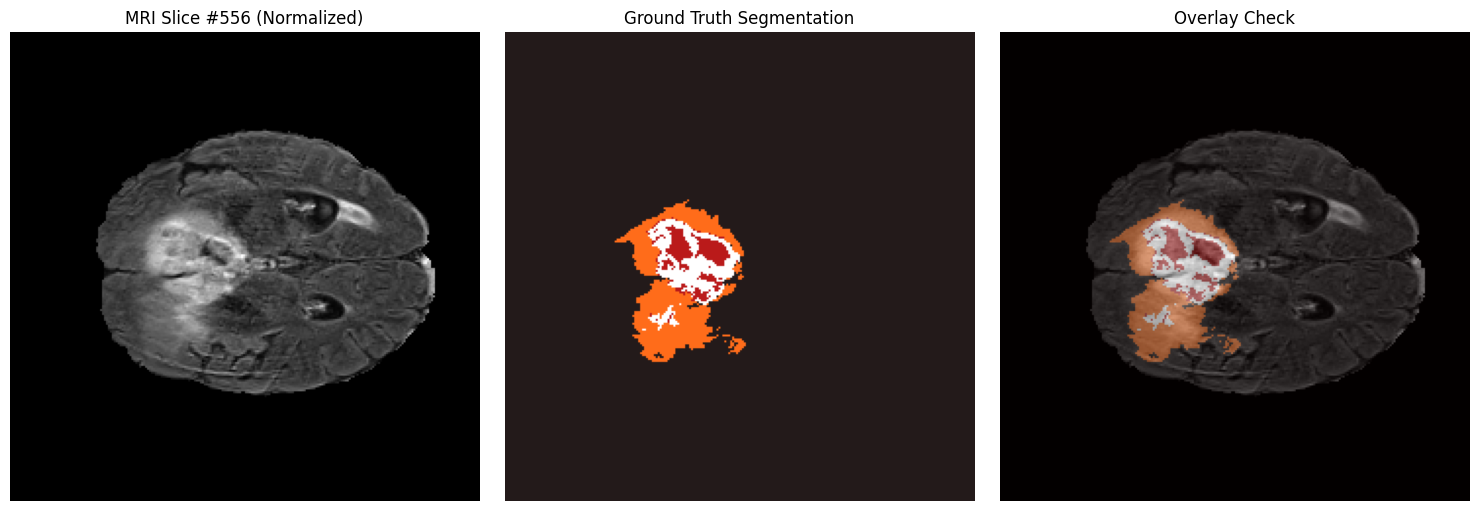

In [5]:
import torch
import os
import matplotlib.pyplot as plt
import random

# --- CONFIGURATION ---
INPUT_FOLDER = 'processed_tumor_packs'

# 1. Find the processed files
pack_files = sorted([f for f in os.listdir(INPUT_FOLDER) if f.endswith('.pt')])

if not pack_files:
    print(f"❌ No .pt files found in {INPUT_FOLDER}. Did the previous step finish?")
else:
    print(f"✅ Found {len(pack_files)} packs. Inspecting the first one: '{pack_files[0]}'...\n")

    # 2. Load the first pack
    # NOTE: map_location='cpu' prevents OOM errors if you are just checking data
    pack_path = os.path.join(INPUT_FOLDER, pack_files[0])
    data_pack = torch.load(pack_path, map_location='cpu', weights_only=True)

    # 3. Print Tensor Statistics
    print("--- 📊 TENSOR STATISTICS ---")
    print(f"Shape:       {data_pack.shape}")
    print(f"             (Batch Size, Channels, Height, Width)")
    print(f"             Note: Channel 0 = MRI Image, Channel 1 = Tumor Mask")
    print(f"Data Type:   {data_pack.dtype}")
    print(f"Memory Size: {data_pack.element_size() * data_pack.numel() / 1e6:.2f} MB")
    
    # Check Normalization (Should be close to -1 and 1)
    img_channel = data_pack[:, 0, :, :]
    print(f"Pixel Range: Min {img_channel.min():.4f} | Max {img_channel.max():.4f}")
    
    # Check Mask (Should be 0 or 1, or close to it if interpolated)
    mask_channel = data_pack[:, 1, :, :]
    print(f"Mask Range:  Min {mask_channel.min():.4f} | Max {mask_channel.max():.4f}")
    print(f"Tumor %:     {(mask_channel > 0).float().mean().item() * 100:.2f}% of pixels in this pack are tumor")

    # 4. Visualization (Sanity Check)
    print("\n--- 👁️ VISUAL CHECK (Random Slice) ---")
    
    # Pick a random index
    idx = random.randint(0, len(data_pack) - 1)
    sample = data_pack[idx]
    
    # Extract Image and Mask
    img = sample[0, :, :].float()
    mask = sample[1, :, :].float()

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # MRI Image
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title(f"MRI Slice #{idx} (Normalized)")
    ax[0].axis('off')
    
    # Tumor Mask
    ax[1].imshow(mask, cmap='hot', alpha=0.9)
    ax[1].set_title("Ground Truth Segmentation")
    ax[1].axis('off')

    # Overlay
    ax[2].imshow(img, cmap='gray')
    ax[2].imshow(mask, cmap='hot', alpha=0.4) # Overlay with transparency
    ax[2].set_title("Overlay Check")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()